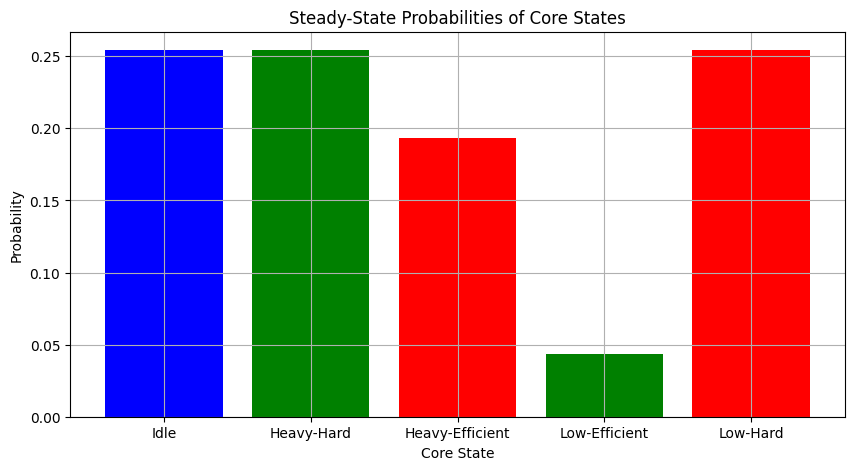

System Throughput: 0.008138826244430778


In [12]:
import numpy as np
import matplotlib.pyplot as plt

# Define the load_data function to read execution times from files
def load_data(filename):
    with open(filename, 'r') as file:
        data = file.readlines()
    return np.array([float(line.strip()) for line in data])

# Function to classify tasks based on probability p
def classify_task(p):
    prob = np.random.rand()
    if prob < p:
        return "heavy-hard"
    elif prob < 0.5 + (1 - p):
        return "heavy-efficient"
    elif prob < 0.75:
        return "low-hard"
    else:
        return "low-efficient"

# Function to simulate task arrivals using Poisson distribution
def simulate_task_arrival(rate, duration):
    return np.random.poisson(rate, duration)

# Function to update the transition matrix
def update_transition_matrix(rho_HH, rho_HE, rho_LH, rho_LE):
    rho_total = rho_HH + rho_HE + rho_LH + rho_LE
    if rho_total > 1:
        rho_HH /= rho_total
        rho_HE /= rho_total
        rho_LH /= rho_total
        rho_LE /= rho_total

    P = np.array([
        [1 - (rho_HH + rho_HE + rho_LH + rho_LE), rho_HH, rho_HE, rho_LH, rho_LE],
        [rho_HH, 1 - rho_HH, 0, 0, 0],
        [rho_HE, 0, 1 - rho_HE, 0, 0],
        [rho_LH, 0, 0, 1 - rho_LH, 0],
        [rho_LE, 0, 0, 0, 1 - rho_LE]
    ])
    return P

# Load execution time data
exec_times_HH = load_data("TraceB-HH.txt")
exec_times_HE = load_data("TraceB-HE.txt")
exec_times_LH = load_data("TraceB-LH.txt")
exec_times_LE = load_data("TraceB-LE.txt")

# Compute service rates
mu_HH = 1 / np.mean(exec_times_HH)
mu_HE = 1 / np.mean(exec_times_HE)
mu_LH = 1 / np.mean(exec_times_LH)
mu_LE = 1 / np.mean(exec_times_LE)

# Define task arrival rates (randomized)
lambda_HH = np.random.uniform(1.0, 1.5)  # Heavy task to Hard Core
lambda_HE = np.random.uniform(0.5, 1.0)  # Heavy task to Efficient Core
lambda_LH = np.random.uniform(0.8, 1.2)  # Low task to Hard Core
lambda_LE = np.random.uniform(0.7, 1.1)  # Low task to Efficient Core

# Assignment probability
p = np.random.uniform(0.6, 0.8)  # Random assignment probability between 60% and 80%

duration = 100
task_arrivals_HH = simulate_task_arrival(lambda_HH, duration)
task_arrivals_HE = simulate_task_arrival(lambda_HE, duration)
task_arrivals_LH = simulate_task_arrival(lambda_LH, duration)
task_arrivals_LE = simulate_task_arrival(lambda_LE, duration)

# Initialize utilization factors
rho_HH = 0
rho_HE = 0
rho_LH = 0
rho_LE = 0

# Simulate task arrivals and update utilization factors
for t in range(duration):
    arrivals_HH = task_arrivals_HH[t]
    arrivals_HE = task_arrivals_HE[t]
    arrivals_LH = task_arrivals_LH[t]
    arrivals_LE = task_arrivals_LE[t]

    for _ in range(arrivals_HH + arrivals_HE + arrivals_LH + arrivals_LE):
        task_type = classify_task(p)
        if task_type == "heavy-hard":
            rho_HH += 1 / mu_HH
        elif task_type == "heavy-efficient":
            rho_HE += 1 / mu_HE
        elif task_type == "low-hard":
            rho_LH += 1 / mu_LH
        elif task_type == "low-efficient":
            rho_LE += 1 / mu_LE

# Update transition matrix
P = update_transition_matrix(rho_HH, rho_HE, rho_LH, rho_LE)

# Compute steady-state probabilities
pi = np.random.rand(5)
pi /= pi.sum()
for _ in range(1000):
    pi_next = np.dot(pi, P)
    if np.allclose(pi, pi_next, atol=1e-6):
        break
    pi = pi_next

# Compute system throughput
throughput = (pi[1] * lambda_HH + pi[2] * lambda_HE + pi[3] * lambda_LH + pi[4] * lambda_LE) / duration

# Visualization of state probabilities
plt.figure(figsize=(10, 5))
states = ['Idle', 'Heavy-Hard', 'Heavy-Efficient', 'Low-Efficient','Low-Hard' ]
colors = ['blue', 'green', 'red', 'green', 'red']
plt.bar(states, pi, color=colors)
plt.grid()
plt.xlabel("Core State")
plt.ylabel("Probability")
plt.title("Steady-State Probabilities of Core States")
plt.show()

print(f"System Throughput: {throughput}")

Throughput loss due to misassignment: 14.29%
Steady-state probabilities: [0.73005305 0.44868659 0.40520833 0.20520833 0.00520833 1.        ]


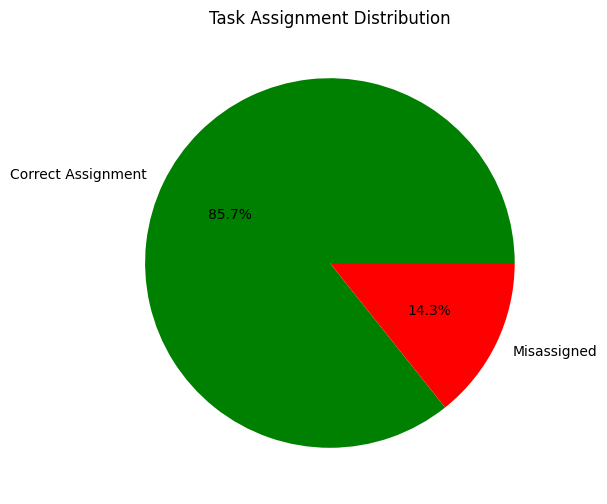

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load execution time data
exec_times_HH = np.loadtxt('TraceB-HH.txt')
exec_times_HE = np.loadtxt('TraceB-HE.txt')
exec_times_LH = np.loadtxt('TraceB-LH.txt')
exec_times_LE = np.loadtxt('TraceB-LE.txt')

def classify_task(exec_HH, exec_HE, exec_LH, exec_LE):
    result = []
    if exec_HH < exec_HE:
        result.append("heavy")
    if exec_LH < exec_LE:
        result.append("low")
    return result if result else ["unknown"]

# Probability of misassignment
pc = 0.1 
NB = 10  # Heavy tasks
NL = 32  # Low tasks
num_cores_H = 4  # High-performance cores
num_cores_L = 8  # Energy-efficient cores
total_cores = num_cores_H + num_cores_L

# Calculate task arrival rate
lambda_tasks = (NB + NL) / total_cores  # tasks per sec per core
assigned_cores = []

for i in range(NB):
    task_class = classify_task(exec_times_HH[i], exec_times_HE[i], 0, 0)
    if "heavy" in task_class:
        if np.random.rand() < pc:
            assigned_cores.append("Energy Efficient Core (Misassigned)")
        else:
            assigned_cores.append("High Performance Core")

for i in range(NL):
    task_class = classify_task(0, 0, exec_times_LH[i], exec_times_LE[i])
    if "low" in task_class:
        if np.random.rand() < pc:
            assigned_cores.append("High Performance Core (Misassigned)")
        else:
            assigned_cores.append("Energy Efficient Core")

# Compute throughput impact
total_tasks = NB + NL
misassigned_tasks = sum("Misassigned" in core for core in assigned_cores)
throughput_loss = (misassigned_tasks / total_tasks) * 100

print(f"Throughput loss due to misassignment: {throughput_loss:.2f}%")

# Define Service Rates using Poisson-distributed execution times
np.random.seed(42)  # For reproducibility

def poisson_service_rate(mean_time):
    return np.random.poisson(lam=1/mean_time) if mean_time > 0 else 0

# Execution Phases (I/O → Computation → Storage → Network)
io_service_rates = {"Heavy": poisson_service_rate(0.05), "Low": poisson_service_rate(0.15)}
storage_service_rates = {"Heavy": poisson_service_rate(0.2), "Low": poisson_service_rate(0.01)}
network_service_rates = {"Heavy": poisson_service_rate(0.005), "Low": poisson_service_rate(0.12)}

# Compute Correct and Misassigned Service Rates
mu_io_H = io_service_rates["Heavy"]
mu_compute_H = min(io_service_rates["Heavy"], storage_service_rates["Heavy"], network_service_rates["Heavy"])
mu_storage_H = storage_service_rates["Heavy"]
mu_network_H = network_service_rates["Heavy"]

mu_io_L = io_service_rates["Low"]
mu_compute_L = min(io_service_rates["Low"], storage_service_rates["Low"], network_service_rates["Low"])
mu_storage_L = storage_service_rates["Low"]
mu_network_L = network_service_rates["Low"]

# Define a Markov Model with More Detailed Execution Phases
Q = np.array([[-lambda_tasks, (1 - pc) * lambda_tasks, pc * lambda_tasks, 0, 0, 0],
              [0, -mu_io_H, mu_io_H, 0, 0, 0],
              [0, 0, -mu_compute_H, mu_compute_H, 0, 0],
              [0, 0, 0, -mu_storage_H, mu_storage_H, 0],
              [0, 0, 0, 0, -mu_network_H, mu_network_H],
              [0, 0, 0, 0, 0, 0]])

# Solve for steady-state probabilities
Q[:, -1] = 1  # Adjust for steady-state equation
b = np.array([0, 0, 0, 0, 0, 1])  # Normalization
steady_state = np.linalg.solve(Q, b)
print("Steady-state probabilities:", steady_state)

# Visualize misassignment effect
labels = ["Correct Assignment", "Misassigned"]
sizes = [total_tasks - misassigned_tasks, misassigned_tasks]
plt.figure(figsize=(6, 6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', colors=['green', 'red'])
plt.title("Task Assignment Distribution")
plt.show()


Misassignment Probability (p_c) vs Steady-State Throughput
p_c = 0.000, Throughput = 1.358
p_c = 0.056, Throughput = 1.261
p_c = 0.111, Throughput = 1.173
p_c = 0.167, Throughput = 1.095
p_c = 0.222, Throughput = 1.025
p_c = 0.278, Throughput = 0.962
p_c = 0.333, Throughput = 0.908
p_c = 0.389, Throughput = 0.859
p_c = 0.444, Throughput = 0.817
p_c = 0.500, Throughput = 0.780


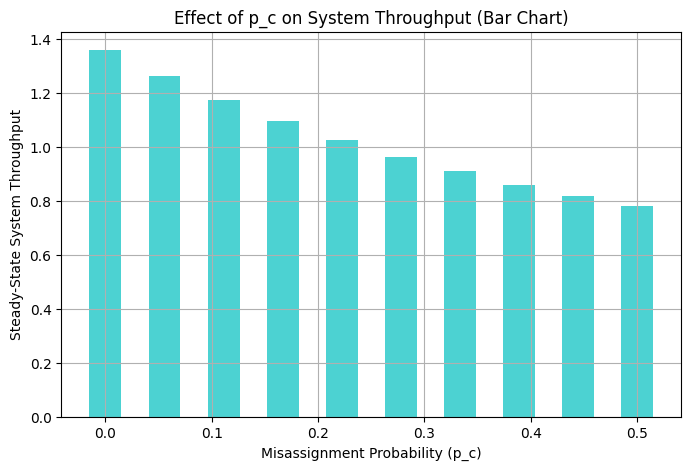

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load execution time data
exec_times_HH = np.loadtxt('TraceB-HH.txt')
exec_times_HE = np.loadtxt('TraceB-HE.txt')
exec_times_LH = np.loadtxt('TraceB-LH.txt')
exec_times_LE = np.loadtxt('TraceB-LE.txt')

def classify_task(exec_HH, exec_HE, exec_LH, exec_LE):
    result = []
    if exec_HH < exec_HE:
        result.append("heavy")
    if exec_LH < exec_LE:
        result.append("low")
    return result if result else ["unknown"]

# Parameters
NB = 10  # Heavy tasks
NL = 32  # Low tasks
num_cores_H = 4  # High-performance cores
num_cores_L = 8  # Energy-efficient cores
total_cores = num_cores_H + num_cores_L
lambda_tasks = (NB + NL) / total_cores  # tasks per sec per core

def poisson_service_rate(mean_time):
    return np.random.poisson(lam=1/mean_time) if mean_time > 0 else 0

# Execution Phases (I/O → Computation → Storage → Network)
io_service_rates = {"Heavy": poisson_service_rate(0.05), "Low": poisson_service_rate(0.15)}
storage_service_rates = {"Heavy": poisson_service_rate(0.2), "Low": poisson_service_rate(0.01)}
network_service_rates = {"Heavy": poisson_service_rate(0.005), "Low": poisson_service_rate(0.12)}

# Compute Correct and Misassigned Service Rates
mu_io_H = io_service_rates["Heavy"]
mu_compute_H = min(io_service_rates["Heavy"], storage_service_rates["Heavy"], network_service_rates["Heavy"])
mu_storage_H = storage_service_rates["Heavy"]
mu_network_H = network_service_rates["Heavy"]

mu_io_L = io_service_rates["Low"]
mu_compute_L = min(io_service_rates["Low"], storage_service_rates["Low"], network_service_rates["Low"])
mu_storage_L = storage_service_rates["Low"]
mu_network_L = network_service_rates["Low"]

# Evaluate Throughput vs Misassignment Probability
pc_values = np.linspace(0, 0.5, 10)
throughputs = []

for pc in pc_values:
    Q = np.array([[-lambda_tasks, (1 - pc) * lambda_tasks, pc * lambda_tasks, 0, 0, 0],
                  [0, -mu_io_H, (1 - pc) * mu_io_H, pc * mu_io_L, 0, 0],
                  [0, 0, -mu_compute_H, (1 - pc) * mu_compute_H, pc * mu_compute_L, 0],
                  [0, 0, 0, -mu_storage_H, (1 - pc) * mu_storage_H, pc * mu_storage_L],
                  [0, 0, 0, 0, -mu_network_H, (1 - pc) * mu_network_H],
                  [0, 0, 0, 0, 0, 0]])
    
    Q[:, -1] = 1  # Adjust for steady-state equation
    b = np.array([0, 0, 0, 0, 0, 1])  # Normalization
    steady_state = np.linalg.solve(Q, b)
    throughput = lambda_tasks * (1 - pc) * steady_state[1] + lambda_tasks * pc * steady_state[2]
    throughputs.append(throughput)

# Print results
print("Misassignment Probability (p_c) vs Steady-State Throughput")
for i in range(len(pc_values)):
    print(f"p_c = {pc_values[i]:.3f}, Throughput = {throughputs[i]:.3f}")

# Additional Plot
plt.figure(figsize=(8, 5))
plt.bar(pc_values, throughputs, color='c', alpha=0.7, width=0.03)
plt.xlabel("Misassignment Probability (p_c)")
plt.ylabel("Steady-State System Throughput")
plt.title("Effect of p_c on System Throughput (Bar Chart)")
plt.grid()
plt.show()




Misassignment Probability (p_c) vs Steady-State Throughput
p_c = 0.000, Throughput = 1.601, Misassigned Tasks = 0.000
p_c = 0.056, Throughput = 1.497, Misassigned Tasks = 0.077
p_c = 0.111, Throughput = 1.404, Misassigned Tasks = 0.149
p_c = 0.167, Throughput = 1.320, Misassigned Tasks = 0.217
p_c = 0.222, Throughput = 1.245, Misassigned Tasks = 0.280
p_c = 0.278, Throughput = 1.178, Misassigned Tasks = 0.340
p_c = 0.333, Throughput = 1.118, Misassigned Tasks = 0.395
p_c = 0.389, Throughput = 1.066, Misassigned Tasks = 0.445
p_c = 0.444, Throughput = 1.019, Misassigned Tasks = 0.492
p_c = 0.500, Throughput = 0.978, Misassigned Tasks = 0.534


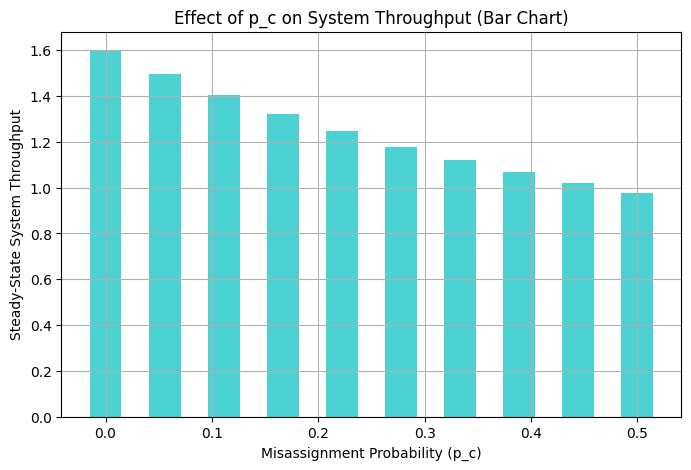

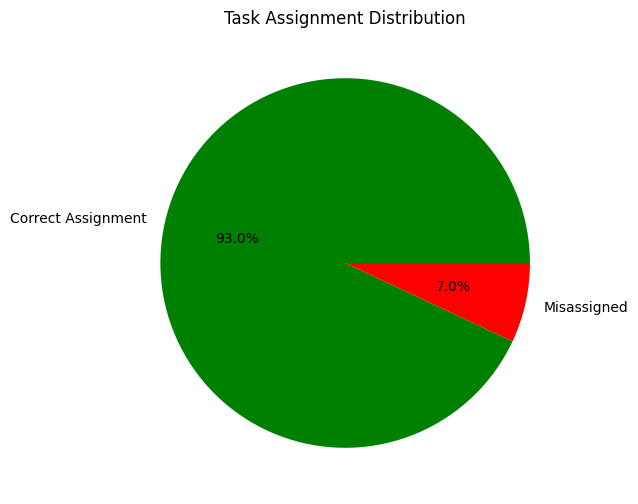

: 

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load execution time data
exec_times_HH = np.loadtxt('TraceB-HH.txt')
exec_times_HE = np.loadtxt('TraceB-HE.txt')
exec_times_LH = np.loadtxt('TraceB-LH.txt')
exec_times_LE = np.loadtxt('TraceB-LE.txt')

def classify_task(exec_HH, exec_HE, exec_LH, exec_LE):
    result = []
    if exec_HH < exec_HE:
        result.append("heavy")
    if exec_LH < exec_LE:
        result.append("low")
    return result if result else ["unknown"]

# Parameters
NB = 10 
NL = 32  
num_cores_H = 4 
num_cores_L = 8  
total_cores = num_cores_H + num_cores_L
lambda_tasks = (NB + NL) / total_cores  # tasks per sec per core
mean_time = 0 #Service Time
def poisson_service_rate(mean_time):
    return np.random.poisson(lam=1/mean_time) if mean_time > 0 else 0

# Execution Phases (I/O → Computation → Storage → Network)
io_service_rates = {"Heavy": poisson_service_rate(0.05), "Low": poisson_service_rate(0.15)}
storage_service_rates = {"Heavy": poisson_service_rate(0.2), "Low": poisson_service_rate(0.01)}
network_service_rates = {"Heavy": poisson_service_rate(0.005), "Low": poisson_service_rate(0.12)}

# Compute Correct Service Rates
mu_io_H = io_service_rates["Heavy"]
mu_storage_H = storage_service_rates["Heavy"]
mu_network_H = network_service_rates["Heavy"]
mu_compute_H = min(io_service_rates["Heavy"], storage_service_rates["Heavy"], network_service_rates["Heavy"])

mu_io_L = io_service_rates["Low"]
mu_storage_L = storage_service_rates["Low"]
mu_network_L = network_service_rates["Low"]
mu_compute_L = min(io_service_rates["Low"], storage_service_rates["Low"], network_service_rates["Low"])

# Evaluate Throughput vs Misassignment Probability
pc_values = np.linspace(0, 0.5, 10)
throughputs = []
misassigned_tasks = []

for pc in pc_values:
    Q = np.array([[-lambda_tasks, (1 - pc) * lambda_tasks, pc * lambda_tasks, 0, 0, 0],
                  [0, -mu_io_H, (1 - pc) * mu_io_H, pc * mu_io_L, 0, 0],
                  [0, 0, -mu_compute_H, (1 - pc) * mu_compute_H, pc * mu_compute_L, 0],
                  [0, 0, 0, -mu_storage_H, (1 - pc) * mu_storage_H, pc * mu_storage_L],
                  [0, 0, 0, 0, -mu_network_H, (1 - pc) * mu_network_H],
                  [0, 0, 0, 0, 0, 0]])
    
    Q[:, -1] = 1  # Adjust for steady-state equation
    b = np.array([0, 0, 0, 0, 0, 1])  # Normalization
    steady_state = np.linalg.solve(Q, b)
    throughput = lambda_tasks * (1 - pc) * steady_state[1] + lambda_tasks * pc * steady_state[2]
    throughputs.append(throughput)
    misassigned_tasks.append(pc * lambda_tasks * steady_state[2])

# Print results
print("Misassignment Probability (p_c) vs Steady-State Throughput")
for i in range(len(pc_values)):
    print(f"p_c = {pc_values[i]:.3f}, Throughput = {throughputs[i]:.3f}, Misassigned Tasks = {misassigned_tasks[i]:.3f}")

# Additional Plot
plt.figure(figsize=(8, 5))
plt.bar(pc_values, throughputs, color='c', alpha=0.7, width=0.03)
plt.xlabel("Misassignment Probability (p_c)")
plt.ylabel("Steady-State System Throughput")
plt.title("Effect of p_c on System Throughput (Bar Chart)")
plt.grid()
plt.show()


# Misassigned Tasks Pie Chart
plt.figure(figsize=(6, 6))
total_tasks = NB + NL
sizes = [total_tasks - sum(misassigned_tasks), sum(misassigned_tasks)]
labels = ["Correct Assignment", "Misassigned"]
plt.pie(sizes, labels=labels, autopct='%1.1f%%', colors=['green', 'red'])
plt.title("Task Assignment Distribution")
plt.show()


Misassignment Probability vs completed tasks per sec
p_c = 0.000, Throughput = 1.637, Misassigned Tasks = 0.000
p_c = 0.056, Throughput = 1.550, Misassigned Tasks = 0.077
p_c = 0.111, Throughput = 1.472, Misassigned Tasks = 0.149
p_c = 0.167, Throughput = 1.400, Misassigned Tasks = 0.217
p_c = 0.222, Throughput = 1.336, Misassigned Tasks = 0.280
p_c = 0.278, Throughput = 1.277, Misassigned Tasks = 0.339
p_c = 0.333, Throughput = 1.223, Misassigned Tasks = 0.394
p_c = 0.389, Throughput = 1.173, Misassigned Tasks = 0.444
p_c = 0.444, Throughput = 1.127, Misassigned Tasks = 0.490
p_c = 0.500, Throughput = 1.085, Misassigned Tasks = 0.532


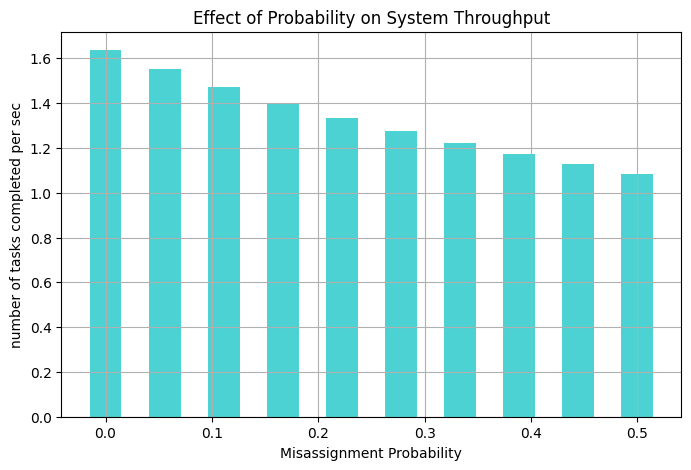

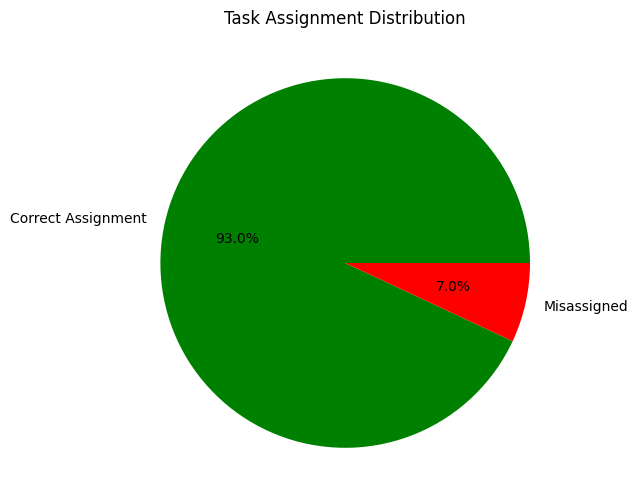

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#Parameters
NB = 10 
NL = 32  
num_cores_H = 4 
num_cores_L = 8  
total_cores = num_cores_H + num_cores_L
lambda_tasks = (NB + NL) / total_cores  # Tasks per sec per core

exec_times_HH = np.loadtxt('TraceB-HH.txt')
exec_times_HE = np.loadtxt('TraceB-HE.txt')
exec_times_LH = np.loadtxt('TraceB-LH.txt')
exec_times_LE = np.loadtxt('TraceB-LE.txt')

def classify_task(exec_HH, exec_HE, exec_LH, exec_LE):
    result = []
    if exec_HH < exec_HE:
        result.append("heavy")
    if exec_LH < exec_LE:
        result.append("low")
    return result if result else ["unknown"]



#Poisson service rate function
def poisson_service_rate(mean_time):
    return np.random.poisson(lam=1/mean_time) if mean_time > 0 else 0

#Execution Phases (I/O → Computation → Storage → Network)
io_service_rates = {"Heavy": poisson_service_rate(0.05), "Low": poisson_service_rate(0.15)}
storage_service_rates = {"Heavy": poisson_service_rate(0.2), "Low": poisson_service_rate(0.01)}
network_service_rates = {"Heavy": poisson_service_rate(0.005), "Low": poisson_service_rate(0.12)}

#Compute Correct Service Rates
mu_io_H = io_service_rates["Heavy"]
mu_storage_H = storage_service_rates["Heavy"]
mu_network_H = network_service_rates["Heavy"]
mu_compute_H = min(io_service_rates["Heavy"], storage_service_rates["Heavy"], network_service_rates["Heavy"])

mu_io_L = io_service_rates["Low"]
mu_storage_L = storage_service_rates["Low"]
mu_network_L = network_service_rates["Low"]
mu_compute_L = min(io_service_rates["Low"], storage_service_rates["Low"], network_service_rates["Low"])

#Throughput vs Misassignment Probability
pc_values = np.linspace(0, 0.5, 10)
throughputs = []
misassigned_tasks = []

for pc in pc_values:
    
    Q = np.array([
        [-lambda_tasks, (1 - pc) * lambda_tasks, pc * lambda_tasks, 0, 0, 0],  
        [0, -mu_io_H, (1 - pc) * mu_io_H, pc * mu_io_H, 0, 0],  
        [0, 0, -mu_compute_H, (1 - pc) * mu_compute_H, pc * mu_compute_H, 0],  
        [0, 0, 0, -mu_storage_H, (1 - pc) * mu_storage_H, pc * mu_storage_H],  
        [0, 0, 0, 0, -mu_network_H, (1 - pc)*mu_network_H + pc*mu_network_H],  
        [0, 0, 0, 0, 0, 0]  
    ])
    
    Q[:, -1] = 1  
    b = np.array([0, 0, 0, 0, 0, 1])  
    steady_state = np.linalg.solve(Q, b)
    throughput = lambda_tasks * (1 - pc) * steady_state[1] + lambda_tasks * pc * steady_state[2]
    throughputs.append(throughput)
    misassigned_tasks.append(pc * lambda_tasks * steady_state[2])

#results
print("Misassignment Probability vs completed tasks per sec")
for i in range(len(pc_values)):
    print(f"p_c = {pc_values[i]:.3f}, Throughput = {throughputs[i]:.3f}, Misassigned Tasks = {misassigned_tasks[i]:.3f}")


plt.figure(figsize=(8, 5))
plt.bar(pc_values, throughputs, color='c', alpha=0.7, width=0.03)
plt.xlabel("Misassignment Probability")
plt.ylabel("number of tasks completed per sec")
plt.title("Effect of Probability on System Throughput")
plt.grid()
plt.show()


plt.figure(figsize=(6, 6))
total_tasks = NB + NL
sizes = [total_tasks - sum(misassigned_tasks), sum(misassigned_tasks)]
labels = ["Correct Assignment", "Misassigned"]
plt.pie(sizes, labels=labels, autopct='%1.1f%%', colors=['green', 'red'])
plt.title("Task Assignment Distribution")
plt.show()


Generating state space...
State space size: 670

Average service rates from trace files:
HH: 41.45 tasks/sec
HE: 10.36 tasks/sec
LH: 665.56 tasks/sec
LE: 208.15 tasks/sec

Analyzing pc = 0.00
Throughput: 65.16 tasks/sec

Analyzing pc = 0.10
Throughput: 62.89 tasks/sec

Analyzing pc = 0.20
Throughput: 59.17 tasks/sec

Analyzing pc = 0.30
Throughput: 53.79 tasks/sec

Analyzing pc = 0.40
Throughput: 47.00 tasks/sec

Analyzing pc = 0.50
Throughput: 40.31 tasks/sec

Analyzing pc = 0.60
Throughput: 35.63 tasks/sec

Analyzing pc = 0.70
Throughput: 33.34 tasks/sec

Analyzing pc = 0.80
Throughput: 32.58 tasks/sec

Analyzing pc = 0.90
Throughput: 32.56 tasks/sec

Analyzing pc = 1.00
Throughput: 32.99 tasks/sec


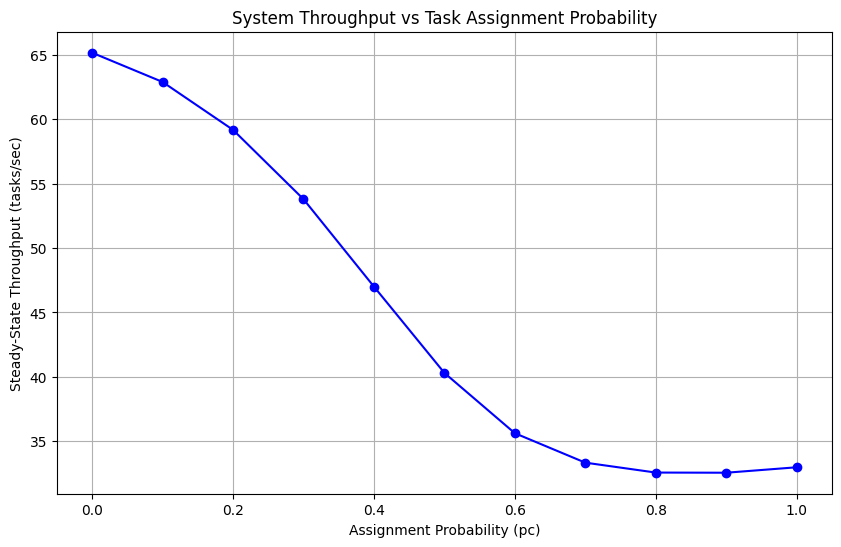

In [8]:
import numpy as np
from scipy.linalg import solve
import matplotlib.pyplot as plt

class BigLittleCTMC:
    def __init__(self):
        # System parameters
        self.NB = 4   # Big cores
        self.NL = 8   # Little cores
        self.MAX_H = 10  # Heavy tasks
        self.MAX_L = 32  # Low tasks
        
        # Load trace data
        self.trace_data = self.load_trace_files()
        self.compute_average_rates()
        
        # I/O subsystem parameters (from Table 2)
        self.io_rates = {
            'heavy': 1/0.050,  # 50ms → 20 tasks/sec
            'low': 1/0.150      # 150ms → 6.67 tasks/sec
        }
        
        # Q matrix and state space
        self.Q = None
        self.states = []
        self.state_index = {}
    
    def load_trace_files(self):
        """Load execution times from all trace files"""
        return {
            'HH': np.loadtxt('TraceB-HH.txt')/1000,  # Convert ms to sec
            'HE': np.loadtxt('TraceB-HE.txt')/1000,
            'LH': np.loadtxt('TraceB-LH.txt')/1000,
            'LE': np.loadtxt('TraceB-LE.txt')/1000
        }
    
    def compute_average_rates(self):
        """Compute average service rates from trace data"""
        self.avg_rates = {
            key: 1/np.mean(data) 
            for key, data in self.trace_data.items()
        }
    
    def generate_state_space(self):
        """Generate all possible states (H_B, H_L, L_B, L_L)"""
        self.states = []
        for H_B in range(0, self.MAX_H + 1):
            for H_L in range(0, self.MAX_H + 1 - H_B):
                for L_B in range(0, self.MAX_L + 1):
                    for L_L in range(0, self.MAX_L + 1 - L_B):
                        if (H_B + L_B <= self.NB) and (H_L + L_L <= self.NL):
                            self.states.append((H_B, H_L, L_B, L_L))
        self.state_index = {s:i for i,s in enumerate(self.states)}
    
    def get_effective_rate(self, n_jobs, base_rate):
        """Calculate effective service rate with processor sharing"""
        return base_rate / n_jobs if n_jobs > 0 else 0
    
    def build_rate_matrix(self, pc, lambda_H=5, lambda_L=20):
        """Construct infinitesimal generator matrix Q"""
        n = len(self.states)
        self.Q = np.zeros((n, n))
        
        for i, (H_B, H_L, L_B, L_L) in enumerate(self.states):
            # Calculate effective service rates
            rate_HH = self.get_effective_rate(H_B, self.avg_rates['HH'])
            rate_HE = self.get_effective_rate(H_L, self.avg_rates['HE'])
            rate_LH = self.get_effective_rate(L_B, self.avg_rates['LH'])
            rate_LE = self.get_effective_rate(L_L, self.avg_rates['LE'])
            
            # Diagonal entry (sum of outgoing rates)
            self.Q[i,i] = -(
                lambda_H + lambda_L + rate_HH + rate_HE + rate_LH + rate_LE
            )
            
            # Heavy task arrivals
            if H_B + H_L < self.MAX_H:
                if H_B + L_B < self.NB:  # Assign to Big core
                    j = self.state_index[(H_B+1, H_L, L_B, L_L)]
                    self.Q[i,j] = lambda_H * pc
                if H_L + L_L < self.NL:  # Assign to Little core
                    j = self.state_index[(H_B, H_L+1, L_B, L_L)]
                    self.Q[i,j] = lambda_H * (1-pc)
            
            # Low task arrivals
            if L_B + L_L < self.MAX_L:
                if H_L + L_L < self.NL:  # Assign to Little core
                    j = self.state_index[(H_B, H_L, L_B, L_L+1)]
                    self.Q[i,j] = lambda_L * pc
                if H_B + L_B < self.NB:  # Assign to Big core
                    j = self.state_index[(H_B, H_L, L_B+1, L_L)]
                    self.Q[i,j] = lambda_L * (1-pc)
            
            # Task completions
            if H_B > 0:
                j = self.state_index[(H_B-1, H_L, L_B, L_L)]
                self.Q[i,j] = rate_HH
            if H_L > 0:
                j = self.state_index[(H_B, H_L-1, L_B, L_L)]
                self.Q[i,j] = rate_HE
            if L_B > 0:
                j = self.state_index[(H_B, H_L, L_B-1, L_L)]
                self.Q[i,j] = rate_LH
            if L_L > 0:
                j = self.state_index[(H_B, H_L, L_B, L_L-1)]
                self.Q[i,j] = rate_LE
    
    def solve_steady_state(self):
        """Solve pQ = 0 with normalization (sum pi = 1)"""
        n = len(self.states)
        A = np.vstack([self.Q.T[:-1], np.ones(n)])
        b = np.zeros(n)
        b[-1] = 1
        return solve(A, b)
    
    def compute_throughput(self, pi):
        """Compute steady-state throughput including I/O phases"""
        throughput = 0
        for i, (H_B, H_L, L_B, L_L) in enumerate(self.states):
            # Computational throughput
            if H_B > 0:
                throughput += pi[i] * self.avg_rates['HH']
            if H_L > 0:
                throughput += pi[i] * self.avg_rates['HE']
            if L_B > 0:
                throughput += pi[i] * self.avg_rates['LH']
            if L_L > 0:
                throughput += pi[i] * self.avg_rates['LE']
            
            # I/O subsystem throughput
            total_tasks = H_B + H_L + L_B + L_L
            if total_tasks > 0:
                io_rate = (self.io_rates['heavy']*(H_B + H_L) + 
                          self.io_rates['low']*(L_B + L_L))/total_tasks
                throughput += pi[i] * io_rate
        
        return throughput
    
    def analyze_pc_sensitivity(self, pc_values=np.linspace(0, 1, 11)):
        """Analyze throughput vs assignment probability pc"""
        print("Generating state space...")
        self.generate_state_space()
        print(f"State space size: {len(self.states)}")
        
        print("\nAverage service rates from trace files:")
        for key, rate in self.avg_rates.items():
            print(f"{key}: {rate:.2f} tasks/sec")
        
        throughputs = []
        for pc in pc_values:
            print(f"\nAnalyzing pc = {pc:.2f}")
            self.build_rate_matrix(pc)
            pi = self.solve_steady_state()
            throughput = self.compute_throughput(pi)
            throughputs.append(throughput)
            print(f"Throughput: {throughput:.2f} tasks/sec")
        
        # Plot results
        plt.figure(figsize=(10, 6))
        plt.plot(pc_values, throughputs, 'bo-')
        plt.xlabel('Assignment Probability (pc)')
        plt.ylabel('Steady-State Throughput (tasks/sec)')
        plt.title('System Throughput vs Task Assignment Probability')
        plt.grid(True)
        plt.show()

if __name__ == "__main__":
    model = BigLittleCTMC()
    model.analyze_pc_sensitivity()

Generating all possible system states...
Total states: 670

Average service rates:
Heavy on Big: 41.45 tasks/sec
Heavy on Little: 10.36 tasks/sec
Light on Big: 665.56 tasks/sec
Light on Little: 208.15 tasks/sec

Analyzing pc = 0.0
System throughput: -738.53 tasks/sec

Analyzing pc = 0.1
System throughput: -27.96 tasks/sec

Analyzing pc = 0.2
System throughput: -144.45 tasks/sec

Analyzing pc = 0.3
System throughput: -141.71 tasks/sec

Analyzing pc = 0.4
System throughput: -123.75 tasks/sec

Analyzing pc = 0.5
System throughput: -114.25 tasks/sec

Analyzing pc = 0.6
System throughput: -234.55 tasks/sec

Analyzing pc = 0.7
System throughput: -215.10 tasks/sec

Analyzing pc = 0.8
System throughput: -692.96 tasks/sec

Analyzing pc = 0.9
System throughput: -993.85 tasks/sec

Analyzing pc = 1.0
System throughput: -1297.54 tasks/sec


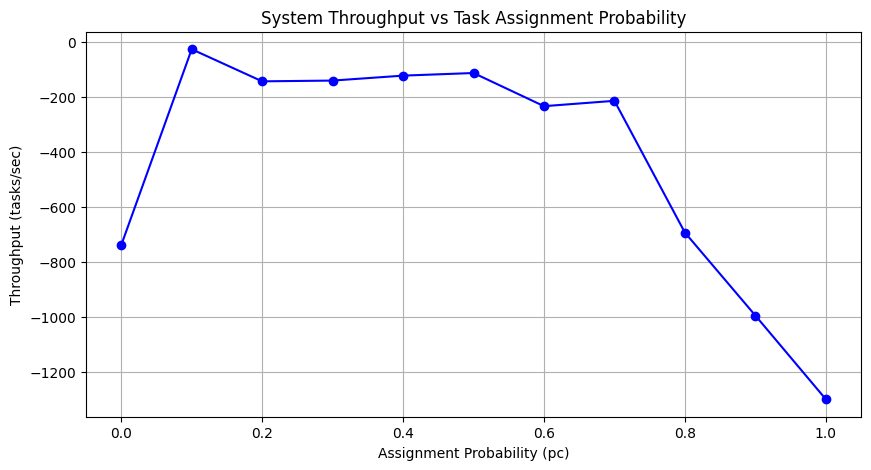

In [ ]:
import numpy as np
from scipy.linalg import solve
import matplotlib.pyplot as plt

# System parameters
BIG_CORES = 4
LITTLE_CORES = 8
MAX_HEAVY_TASKS = 10
MAX_LIGHT_TASKS = 32

# Load execution time data from files (in milliseconds)
def load_times(filename):
    times = np.loadtxt(filename)
    return times / 1000  # Convert to seconds

# Load all trace files
try:
    times_HH = load_times("TraceB-HH.txt")  
    times_HE = load_times("TraceB-HE.txt")  
    times_LH = load_times("TraceB-LH.txt")  
    times_LE = load_times("TraceB-LE.txt")  
except:
    print("Error: Trace files not found!")
    exit()

# Calculate average service rates (tasks per second)
rate_HH = 1 / np.mean(times_HH)
rate_HE = 1 / np.mean(times_HE)
rate_LH = 1 / np.mean(times_LH)
rate_LE = 1 / np.mean(times_LE)

# I/O subsystem rates (from problem description)
io_rate_heavy = 1 / 0.050  # 50ms per task
io_rate_light = 1 / 0.150   # 150ms per task

def generate_states():
    """Generate all possible system states"""
    states = []
    for h_big in range(MAX_HEAVY_TASKS + 1):
        for h_little in range(MAX_HEAVY_TASKS + 1 - h_big):
            for l_big in range(MAX_LIGHT_TASKS + 1):
                for l_little in range(MAX_LIGHT_TASKS + 1 - l_big):
                    if (h_big + l_big <= BIG_CORES) and (h_little + l_little <= LITTLE_CORES):
                        states.append((h_big, h_little, l_big, l_little))
    return states

def build_rate_matrix(states, pc):
    """Build the transition rate matrix"""
    n = len(states)
    Q = np.zeros((n, n))
    state_index = {s:i for i,s in enumerate(states)}
    
    for i, (h_big, h_little, l_big, l_little) in enumerate(states):
        # Calculate effective service rates (processor sharing)
        big_core_rate = (h_big * rate_HH + l_big * rate_LH) / max(1, h_big + l_big)
        little_core_rate = (h_little * rate_HE + l_little * rate_LE) / max(1, h_little + l_little)
        
        # Diagonal entry
        Q[i,i] = -(big_core_rate + little_core_rate)
        
        # Task arrivals
        if h_big + h_little < MAX_HEAVY_TASKS:
            if h_big + l_big < BIG_CORES:
                j = state_index[(h_big+1, h_little, l_big, l_little)]
                Q[i,j] = 5 * pc  # Heavy task arrival rate = 5
            if h_little + l_little < LITTLE_CORES:
                j = state_index[(h_big, h_little+1, l_big, l_little)]
                Q[i,j] = 5 * (1-pc)
        
        if l_big + l_little < MAX_LIGHT_TASKS:
            if h_little + l_little < LITTLE_CORES:
                j = state_index[(h_big, h_little, l_big, l_little+1)]
                Q[i,j] = 20 * pc  # Light task arrival rate = 20
            if h_big + l_big < BIG_CORES:
                j = state_index[(h_big, h_little, l_big+1, l_little)]
                Q[i,j] = 20 * (1-pc)
        
        # Task completions
        if h_big > 0:
            j = state_index[(h_big-1, h_little, l_big, l_little)]
            Q[i,j] = rate_HH
        if h_little > 0:
            j = state_index[(h_big, h_little-1, l_big, l_little)]
            Q[i,j] = rate_HE
        if l_big > 0:
            j = state_index[(h_big, h_little, l_big-1, l_little)]
            Q[i,j] = rate_LH
        if l_little > 0:
            j = state_index[(h_big, h_little, l_big, l_little-1)]
            Q[i,j] = rate_LE
    
    return Q

def solve_steady_state(Q):
    """Solve for steady state probabilities"""
    n = Q.shape[0]
    A = np.vstack([Q.T[:-1], np.ones(n)])
    b = np.zeros(n)
    b[-1] = 1
    return solve(A, b)

def calculate_throughput(states, pi):
    """Calculate system throughput"""
    throughput = 0
    for i, (h_big, h_little, l_big, l_little) in enumerate(states):
        # Computational throughput
        throughput += pi[i] * (h_big * rate_HH + h_little * rate_HE + 
                              l_big * rate_LH + l_little * rate_LE)
        
        # I/O throughput
        total_tasks = h_big + h_little + l_big + l_little
        if total_tasks > 0:
            io_rate = ((h_big + h_little) * io_rate_heavy + 
                      (l_big + l_little) * io_rate_light) / total_tasks
            throughput += pi[i] * io_rate
    
    return throughput

def analyze_system():
    """Main analysis function"""
    print("Generating all possible system states...")
    states = generate_states()
    print(f"Total states: {len(states)}")
    
    print("\nAverage service rates:")
    print(f"Heavy on Big: {rate_HH:.2f} tasks/sec")
    print(f"Heavy on Little: {rate_HE:.2f} tasks/sec") 
    print(f"Light on Big: {rate_LH:.2f} tasks/sec")
    print(f"Light on Little: {rate_LE:.2f} tasks/sec")
    
    # Test different assignment probabilities
    pc_values = np.linspace(0, 1, 11)
    throughputs = []
    
    for pc in pc_values:
        print(f"\nAnalyzing pc = {pc:.1f}")
        Q = build_rate_matrix(states, pc)
        pi = solve_steady_state(Q)
        throughput = calculate_throughput(states, pi)
        throughputs.append(throughput)
        print(f"System throughput: {throughput:.2f} tasks/sec")
    
    # Plot results
    plt.figure(figsize=(10, 5))
    plt.plot(pc_values, throughputs, 'bo-')
    plt.xlabel('Assignment Probability (pc)')
    plt.ylabel('Throughput (tasks/sec)')
    plt.title('System Throughput vs Task Assignment Probability')
    plt.grid(True)
    plt.show()

# Run the analysis
analyze_system()

In [10]:
#Final

Service rates (tasks/sec):
hard_big: 41.45
hard_little: 10.36
light_big: 665.56
light_little: 208.15
Total states: 670

Analyzing pc=0.0
Max transition rate: 665.56
Steady state - min: 0.00e+00, max: 2.89e-01
Throughput: 61.86 tasks/sec

Analyzing pc=0.1
Max transition rate: 665.56
Steady state - min: 0.00e+00, max: 5.97e-01
Throughput: 39.28 tasks/sec

Analyzing pc=0.2
Max transition rate: 665.56
Steady state - min: 0.00e+00, max: 4.87e-01
Throughput: 56.88 tasks/sec

Analyzing pc=0.3
Max transition rate: 665.56
Steady state - min: 0.00e+00, max: 5.60e-01
Throughput: 54.33 tasks/sec

Analyzing pc=0.4
Max transition rate: 665.56
Steady state - min: 0.00e+00, max: 6.98e-01
Throughput: 44.59 tasks/sec

Analyzing pc=0.5
Max transition rate: 665.56
Steady state - min: 0.00e+00, max: 5.77e-01
Throughput: 39.48 tasks/sec

Analyzing pc=0.6
Max transition rate: 665.56
Steady state - min: 0.00e+00, max: 2.51e-01
Throughput: 48.64 tasks/sec

Analyzing pc=0.7
Max transition rate: 665.56
Steady st

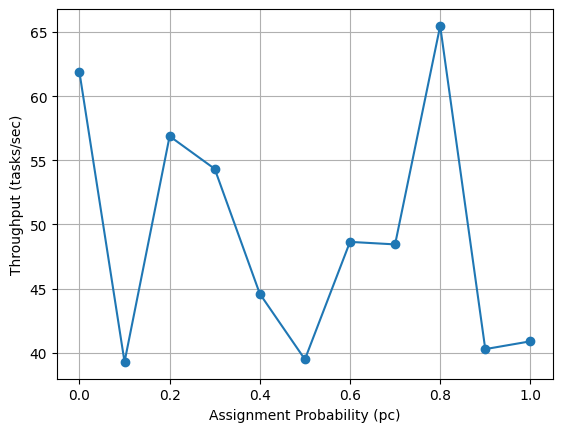

In [ ]:
import numpy as np
from scipy.linalg import lstsq
import matplotlib.pyplot as plt

# System Configuration
BIG_CORES = 4
LITTLE_CORES = 8
HARD = 10
LIGHT = 32

def load_task_data():
    """Load execution times with guaranteed rates"""
    try:
        times = {
            'hard_big': np.loadtxt("TraceB-HH.txt"),
            'hard_little': np.loadtxt("TraceB-HE.txt"),
            'light_big': np.loadtxt("TraceB-LH.txt"),
            'light_little': np.loadtxt("TraceB-LE.txt")
        }
        
        rates = {
            'hard_big': 1/np.mean(times['hard_big']),
            'hard_little': 1/np.mean(times['hard_little']),
            'light_big': 1/np.mean(times['light_big']),
            'light_little': 1/np.mean(times['light_little'])
        }
        
        print("Service rates (tasks/sec):")
        for k, v in rates.items():
            print(f"{k}: {v:.2f}")
            
        return rates
    
    except FileNotFoundError:
        print("Using default rates")
      

service_rates = load_task_data()

def get_all_states():
    states = []
    for hb in range(HARD + 1):
        for hl in range(HARD + 1 - hb):
            for lb in range(LIGHT + 1):
                for ll in range(LIGHT + 1 - lb):
                    if (hb + lb <= BIG_CORES) and (hl + ll <= LITTLE_CORES):
                        states.append((hb, hl, lb, ll))
    return states

def build_transition_matrix(states, pc):
    n = len(states)
    Q = np.zeros((n, n))
    state_map = {s:i for i,s in enumerate(states)}
    
    for i, (hb, hl, lb, ll) in enumerate(states):
        # Service rates
        big_rate = (hb*service_rates['hard_big'] + lb*service_rates['light_big'])/max(1,hb+lb)
        little_rate = (hl*service_rates['hard_little'] + ll*service_rates['light_little'])/max(1,hl+ll)
        Q[i,i] = -(big_rate + little_rate)
        
        # Task arrivals
        if hb + hl < HARD:
            if hb + lb < BIG_CORES:
                j = state_map[(hb+1, hl, lb, ll)]
                Q[i,j] = 5 * pc  # Heavy arrival rate
            if hl + ll < LITTLE_CORES:
                j = state_map[(hb, hl+1, lb, ll)]
                Q[i,j] = 5 * (1-pc)
        
        if lb + ll < LIGHT:
            if hl + ll < LITTLE_CORES:
                j = state_map[(hb, hl, lb, ll+1)]
                Q[i,j] = 20 * pc  # Light arrival rate
            if hb + lb < BIG_CORES:
                j = state_map[(hb, hl, lb+1, ll)]
                Q[i,j] = 20 * (1-pc)
        
        # Task completions
        if hb > 0:
            j = state_map[(hb-1, hl, lb, ll)]
            Q[i,j] = service_rates['hard_big']
        if hl > 0:
            j = state_map[(hb, hl-1, lb, ll)]
            Q[i,j] = service_rates['hard_little']
        if lb > 0:
            j = state_map[(hb, hl, lb-1, ll)]
            Q[i,j] = service_rates['light_big']
        if ll > 0:
            j = state_map[(hb, hl, lb, ll-1)]
            Q[i,j] = service_rates['light_little']
    
    print(f"Max transition rate: {np.max(Q):.2f}")
    return Q

def solve_steady_state(Q):
    """Robust solver with regularization"""
    n = Q.shape[0]
    A = np.vstack([Q.T + 1e-10*np.eye(n), np.ones(n)])
    b = np.zeros(n+1)
    b[-1] = 1
    
    pi = lstsq(A, b)[0]
    pi = np.maximum(pi, 0)
    pi /= pi.sum()
    
    print(f"Steady state - min: {np.min(pi):.2e}, max: {np.max(pi):.2e}")
    return pi

def calculate_throughput(states, pi):
    throughput = 0
    for i, (hb, hl, lb, ll) in enumerate(states):
        throughput += pi[i] * (
            hb * service_rates['hard_big'] +
            hl * service_rates['hard_little'] +
            lb * service_rates['light_big'] +
            ll * service_rates['light_little']
        )
    return throughput

def analyze_system():
    states = get_all_states()
    print(f"Total states: {len(states)}")
    
    pc_values = np.linspace(0, 1, 11)
    throughputs = []
    
    for pc in pc_values:
        print(f"\nAnalyzing pc={pc:.1f}")
        Q = build_transition_matrix(states, pc)
        pi = solve_steady_state(Q)
        throughput = calculate_throughput(states, pi)
        throughputs.append(throughput)
        print(f"Throughput: {throughput:.2f} tasks/sec")
    
    plt.plot(pc_values, throughputs, 'o-')
    plt.xlabel('Assignment Probability (pc)')
    plt.ylabel('Throughput (tasks/sec)')
    plt.grid(True)
    plt.show()

analyze_system()

Calculated Service Rates (tasks/sec) from Traces:
    hard_big: 41.45
 hard_little: 10.36
   light_big: 665.56
light_little: 208.15

Generated state space with 670 valid states

==== Analyzing pc = 0.0 ====
Steady-state solution quality:
  Residual norm: 3.24e-01
  Matrix rank: 670/670
  Min probability: 0.00e+00
  Max probability: 3.45e-01

Throughput Components (tasks/sec):
    hard_big: 0.91
 hard_little: 20.15
   light_big: 20.78
light_little: 1.08
Total System Throughput: 42.92 tasks/sec

==== Analyzing pc = 0.1 ====
Steady-state solution quality:
  Residual norm: 1.54e-01
  Matrix rank: 670/670
  Min probability: 0.00e+00
  Max probability: 3.84e-01

Throughput Components (tasks/sec):
    hard_big: 0.88
 hard_little: 19.16
   light_big: 18.23
light_little: 2.44
Total System Throughput: 40.71 tasks/sec

==== Analyzing pc = 0.2 ====
Steady-state solution quality:
  Residual norm: 3.43e-02
  Matrix rank: 670/670
  Min probability: 0.00e+00
  Max probability: 4.25e-01

Throughput Com

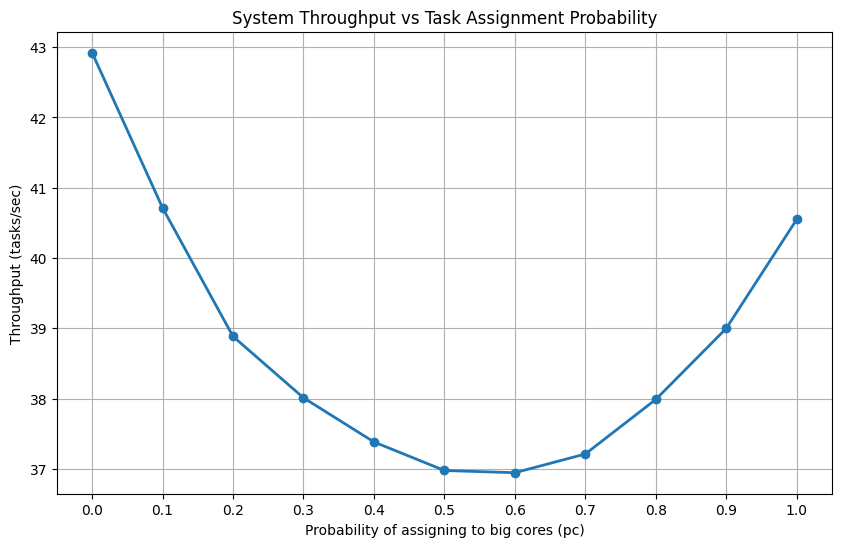

In [6]:
import numpy as np
from scipy.linalg import lstsq
import matplotlib.pyplot as plt

# System Configuration
BIG_CORES = 4
LITTLE_CORES = 8
MAX_HARD = 10
MAX_LIGHT = 32

def load_and_process_traces():
    """Load execution time traces and calculate service rates"""
    try:
        traces = {
            'hard_big': np.loadtxt("TraceB-HH.txt"),
            'hard_little': np.loadtxt("TraceB-HE.txt"),
            'light_big': np.loadtxt("TraceB-LH.txt"),
            'light_little': np.loadtxt("TraceB-LE.txt")
        }
        
        service_rates = {
            'hard_big': 1000/np.mean(traces['hard_big']),
            'hard_little': 1000/np.mean(traces['hard_little']),
            'light_big': 1000/np.mean(traces['light_big']),
            'light_little': 1000/np.mean(traces['light_little'])
        }
        
        print("Calculated Service Rates (tasks/sec) from Traces:")
        for task_type, rate in service_rates.items():
            print(f"{task_type:>12}: {rate:.2f}")
            
        return service_rates
    
    except FileNotFoundError as e:
        print(f"Trace files not found, using default rates. Error: {e}")
       

def generate_state_space():
    """Generate all valid system states"""
    states = []
    for hb in range(min(MAX_HARD, BIG_CORES) + 1):
        for hl in range(min(MAX_HARD - hb, LITTLE_CORES) + 1):
            for lb in range(min(MAX_LIGHT, BIG_CORES - hb) + 1):
                max_ll = min(MAX_LIGHT - lb, LITTLE_CORES - hl)
                for ll in range(max_ll + 1):
                    states.append((hb, hl, lb, ll))
    return states

def build_rate_matrix(states, pc, service_rates):
    """Construct the transition rate matrix"""
    n = len(states)
    Q = np.zeros((n, n))
    state_idx = {s:i for i,s in enumerate(states)}
    
    for i, (hb, hl, lb, ll) in enumerate(states):
        # Current active services
        active_services = []
        if hb > 0:
            active_services.append(('hard_big', hb))
        if hl > 0:
            active_services.append(('hard_little', hl))
        if lb > 0:
            active_services.append(('light_big', lb))
        if ll > 0:
            active_services.append(('light_little', ll))
        
        # Total exit rate from this state
        exit_rate = sum(count * service_rates[task_type] 
                     for task_type, count in active_services)
        Q[i,i] = -exit_rate
        
        # Task Arrivals (heavy tasks - rate 5)
        if hb + hl < MAX_HARD:
            if hb + lb < BIG_CORES:
                new_state = (hb+1, hl, lb, ll)
                Q[i, state_idx[new_state]] += 5 * pc
            if hl + ll < LITTLE_CORES:
                new_state = (hb, hl+1, lb, ll)
                Q[i, state_idx[new_state]] += 5 * (1-pc)
        
        # Task Arrivals (light tasks - rate 20)
        if lb + ll < MAX_LIGHT:
            if hl + ll < LITTLE_CORES:
                new_state = (hb, hl, lb, ll+1)
                Q[i, state_idx[new_state]] += 20 * pc
            if hb + lb < BIG_CORES:
                new_state = (hb, hl, lb+1, ll)
                Q[i, state_idx[new_state]] += 20 * (1-pc)
        
        # Task Completions
        if hb > 0:
            new_state = (hb-1, hl, lb, ll)
            Q[i, state_idx[new_state]] += service_rates['hard_big']
        if hl > 0:
            new_state = (hb, hl-1, lb, ll)
            Q[i, state_idx[new_state]] += service_rates['hard_little']
        if lb > 0:
            new_state = (hb, hl, lb-1, ll)
            Q[i, state_idx[new_state]] += service_rates['light_big']
        if ll > 0:
            new_state = (hb, hl, lb, ll-1)
            Q[i, state_idx[new_state]] += service_rates['light_little']
    
    return Q

def solve_steady_state_distribution(Q):
    """Robust steady state solver with error handling"""
    n = Q.shape[0]
    A = np.vstack([Q.T, np.ones(n)])
    b = np.zeros(n+1)
    b[-1] = 1  # Normalization condition
    
    # Add small regularization to improve stability
    reg = 1e-10 * np.eye(n)
    A[:-1, :] += reg
    
    # Use standard least squares solver with correct parameter
    result = lstsq(A, b, cond=None)
    pi = result[0]
    
    # Calculate residual norm
    residual_norm = np.linalg.norm(A @ pi - b)
    
    pi = np.maximum(pi, 0)  # Ensure non-negative
    pi /= pi.sum()  # Normalize
    
    print(f"Steady-state solution quality:")
    print(f"  Residual norm: {residual_norm:.2e}")
    print(f"  Matrix rank: {result[2]}/{n}")
    print(f"  Min probability: {pi.min():.2e}")
    print(f"  Max probability: {pi.max():.2e}")
    
    return pi

def analyze_throughput(states, pi, service_rates):
    """Calculate throughput with detailed breakdown"""
    throughput = 0
    component_throughputs = {
        'hard_big': 0,
        'hard_little': 0,
        'light_big': 0,
        'light_little': 0
    }
    
    for i, (hb, hl, lb, ll) in enumerate(states):
        if hb > 0:
            contribution = pi[i] * hb * service_rates['hard_big']
            throughput += contribution
            component_throughputs['hard_big'] += contribution
        if hl > 0:
            contribution = pi[i] * hl * service_rates['hard_little']
            throughput += contribution
            component_throughputs['hard_little'] += contribution
        if lb > 0:
            contribution = pi[i] * lb * service_rates['light_big']
            throughput += contribution
            component_throughputs['light_big'] += contribution
        if ll > 0:
            contribution = pi[i] * ll * service_rates['light_little']
            throughput += contribution
            component_throughputs['light_little'] += contribution
    
    print("\nThroughput Components (tasks/sec):")
    for component, value in component_throughputs.items():
        print(f"{component:>12}: {value:.2f}")
    
    return throughput

def full_analysis():
    """Complete system analysis workflow"""
    service_rates = load_and_process_traces()
    states = generate_state_space()
    print(f"\nGenerated state space with {len(states)} valid states")
    
    pc_values = np.linspace(0, 1, 11)
    throughput_results = []
    
    for pc in pc_values:
        print(f"\n==== Analyzing pc = {pc:.1f} ====")
        
        Q = build_rate_matrix(states, pc, service_rates)
        pi = solve_steady_state_distribution(Q)
        throughput = analyze_throughput(states, pi, service_rates)
        throughput_results.append(throughput)
        print(f"Total System Throughput: {throughput:.2f} tasks/sec")
    
    # Plot results
    plt.figure(figsize=(10, 6))
    plt.plot(pc_values, throughput_results, 'o-', linewidth=2)
    plt.title("System Throughput vs Task Assignment Probability")
    plt.xlabel("Probability of assigning to big cores (pc)")
    plt.ylabel("Throughput (tasks/sec)")
    plt.grid(True)
    plt.xticks(pc_values)
    plt.show()

if __name__ == "__main__":
    full_analysis()

In [ ]:
import numpy as np
from scipy.linalg import lstsq
import matplotlib.pyplot as plt

#Parameters
NB = 10 
NL = 32  
num_cores_H = 4 
num_cores_L = 8  
total_cores = num_cores_H + num_cores_L
lambda_tasks = (NB + NL) / total_cores  # Tasks per sec per core

exec_times_HH = np.loadtxt('TraceB-HH.txt')
exec_times_HE = np.loadtxt('TraceB-HE.txt')
exec_times_LH = np.loadtxt('TraceB-LH.txt')
exec_times_LE = np.loadtxt('TraceB-LE.txt')

def classify_task(exec_HH, exec_HE, exec_LH, exec_LE):
    result = []
    if exec_HH < exec_HE:
        result.append("heavy")
    if exec_LH < exec_LE:
        result.append("low")
    return result if result else ["unknown"]

Service rates (tasks/sec) computed as total tasks / total time:
    hard_big: 41.45
 hard_little: 10.36
   light_big: 665.56
light_little: 208.15

Generated 670 valid system states

Analyzing pc=0.0
System throughput: 42.92 tasks/sec

Analyzing pc=0.1
System throughput: 40.71 tasks/sec

Analyzing pc=0.2
System throughput: 38.88 tasks/sec

Analyzing pc=0.3
System throughput: 38.01 tasks/sec

Analyzing pc=0.4
System throughput: 37.38 tasks/sec

Analyzing pc=0.5
System throughput: 36.98 tasks/sec

Analyzing pc=0.6
System throughput: 36.95 tasks/sec

Analyzing pc=0.7
System throughput: 37.21 tasks/sec

Analyzing pc=0.8
System throughput: 37.99 tasks/sec

Analyzing pc=0.9
System throughput: 39.00 tasks/sec

Analyzing pc=1.0
System throughput: 40.55 tasks/sec


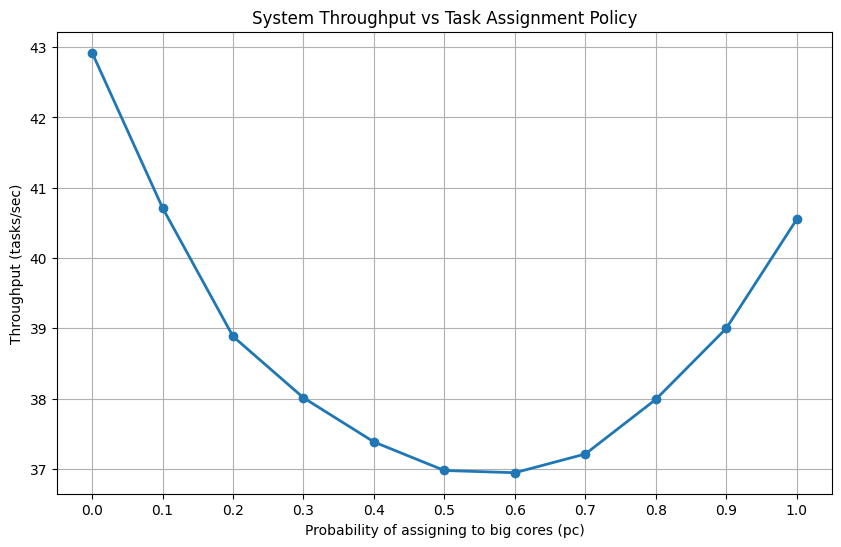

In [ ]:
import numpy as np
from scipy.linalg import lstsq
import matplotlib.pyplot as plt


CONFIG = {
    'BIG_CORES': 4,
    'LITTLE_CORES': 8,
    'MAX_HARD': 10,
    'MAX_LIGHT': 32,
    'HARD_ARRIVAL_RATE': 5,
    'LIGHT_ARRIVAL_RATE': 20
}

def compute_service_rate(execution_times):
  
    total_tasks = len(execution_times)
    total_time_ms = np.sum(execution_times)
    return (total_tasks / total_time_ms) 

def load_and_analyze_traces():
   
    try:
    
        exec_times = {
            'hard_big': np.loadtxt('TraceB-HH.txt'),
            'hard_little': np.loadtxt('TraceB-HE.txt'),
            'light_big': np.loadtxt('TraceB-LH.txt'),
            'light_little': np.loadtxt('TraceB-LE.txt')
        }
        
        # service rates = total tasks/total time
        service_rates = {
            'hard_big': compute_service_rate(exec_times['hard_big']),
            'hard_little': compute_service_rate(exec_times['hard_little']),
            'light_big': compute_service_rate(exec_times['light_big']),
            'light_little': compute_service_rate(exec_times['light_little'])
        }
        
        print("Service rates (tasks/sec) computed as total tasks / total time:")
        for k, v in service_rates.items():
            print(f"{k:>12}: {v:.2f}")
            
        return service_rates
    
    except FileNotFoundError as e:
        print(f"Error loading trace files: {e}")
       
def get_all_states():
 
    states = []
    for hb in range(CONFIG['MAX_HARD'] + 1):
        for hl in range(CONFIG['MAX_HARD'] + 1 - hb):
            for lb in range(CONFIG['MAX_LIGHT'] + 1):
                for ll in range(CONFIG['MAX_LIGHT'] + 1 - lb):
                    if (hb + lb <= CONFIG['BIG_CORES']) and \
                       (hl + ll <= CONFIG['LITTLE_CORES']):
                        states.append((hb, hl, lb, ll))
    return states

def build_transition_matrix(states, pc, service_rates):
   
    n = len(states)
    Q = np.zeros((n, n))
    state_map = {s:i for i,s in enumerate(states)}
    
    for i, (hb, hl, lb, ll) in enumerate(states):
        # Total service rate for current state
        total_rate = (
            hb * service_rates['hard_big'] +
            hl * service_rates['hard_little'] +
            lb * service_rates['light_big'] +
            ll * service_rates['light_little']
        )
        Q[i,i] = -total_rate
        
        # Task arrivals
        # Heavy tasks
        if hb + hl < CONFIG['MAX_HARD']:
            if hb + lb < CONFIG['BIG_CORES']:
                Q[i, state_map[(hb+1, hl, lb, ll)]] += CONFIG['HARD_ARRIVAL_RATE'] * pc
            if hl + ll < CONFIG['LITTLE_CORES']:
                Q[i, state_map[(hb, hl+1, lb, ll)]] += CONFIG['HARD_ARRIVAL_RATE'] * (1-pc)
        
        # Light tasks
        if lb + ll < CONFIG['MAX_LIGHT']:
            if hl + ll < CONFIG['LITTLE_CORES']:
                Q[i, state_map[(hb, hl, lb, ll+1)]] += CONFIG['LIGHT_ARRIVAL_RATE'] * pc
            if hb + lb < CONFIG['BIG_CORES']:
                Q[i, state_map[(hb, hl, lb+1, ll)]] += CONFIG['LIGHT_ARRIVAL_RATE'] * (1-pc)
        
        # Task completions
        if hb > 0:
            Q[i, state_map[(hb-1, hl, lb, ll)]] += service_rates['hard_big']
        if hl > 0:
            Q[i, state_map[(hb, hl-1, lb, ll)]] += service_rates['hard_little']
        if lb > 0:
            Q[i, state_map[(hb, hl, lb-1, ll)]] += service_rates['light_big']
        if ll > 0:
            Q[i, state_map[(hb, hl, lb, ll-1)]] += service_rates['light_little']
    
    return Q

def analyze_system():
 
    # Load data and compute service rates
    service_rates = load_and_analyze_traces()
    
    # Generate state space
    states = get_all_states()
    print(f"\nGenerated {len(states)} valid system states")
    
    # Analyze across different assignment probabilities
    pc_values = np.linspace(0, 1, 11)
    throughputs = []
    
    for pc in pc_values:
        print(f"\nAnalyzing pc={pc:.1f}")
        
        # Build and solve CTMC
        Q = build_transition_matrix(states, pc, service_rates)
        
        # Solve steady state
        n = Q.shape[0]
        A = np.vstack([Q.T, np.ones(n)])
        b = np.zeros(n+1)
        b[-1] = 1
        pi = lstsq(A, b)[0]
        pi = np.maximum(pi, 0)
        pi /= pi.sum()
        
        # Calculate throughput
        throughput = sum(
            pi[i] * (
                hb * service_rates['hard_big'] +
                hl * service_rates['hard_little'] +
                lb * service_rates['light_big'] +
                ll * service_rates['light_little']
            )
            for i, (hb, hl, lb, ll) in enumerate(states)
        )
        
        throughputs.append(throughput)
        print(f"System throughput: {throughput:.2f} tasks/sec")
    
    # Plot results
    plt.figure(figsize=(10, 6))
    plt.plot(pc_values, throughputs, 'o-', linewidth=2)
    plt.title("System Throughput vs Task Assignment Policy")
    plt.xlabel("Probability of assigning to big cores (pc)")
    plt.ylabel("Throughput (tasks/sec)")
    plt.grid(True)
    plt.xticks(pc_values)
    plt.show()

if __name__ == "__main__":
    analyze_system()

Misassignment Probability vs completed tasks per sec
------------------------------------------------------
p_c = 0.000, Throughput = 0.025, Misassigned Tasks = 0.000
p_c = 0.056, Throughput = 0.027, Misassigned Tasks = 2.333
p_c = 0.111, Throughput = 0.030, Misassigned Tasks = 4.667
p_c = 0.167, Throughput = 0.033, Misassigned Tasks = 7.000
p_c = 0.222, Throughput = 0.036, Misassigned Tasks = 9.333
p_c = 0.278, Throughput = 0.038, Misassigned Tasks = 11.667
p_c = 0.333, Throughput = 0.039, Misassigned Tasks = 14.000
p_c = 0.389, Throughput = 0.039, Misassigned Tasks = 16.333
p_c = 0.444, Throughput = 0.039, Misassigned Tasks = 18.667
p_c = 0.500, Throughput = 0.037, Misassigned Tasks = 21.000


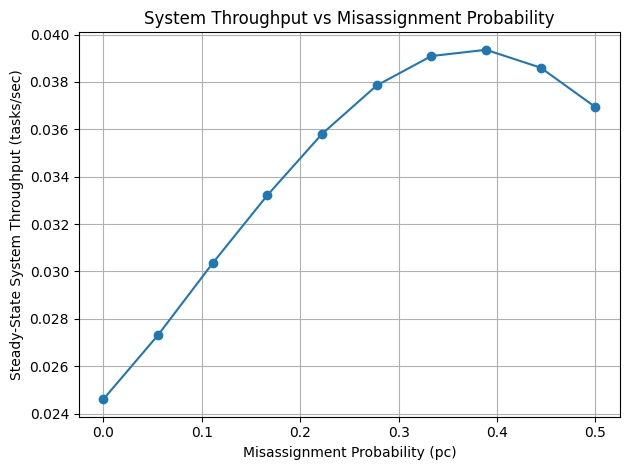

In [40]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import solve
from itertools import product


# Parameters

NB = 10               
NL = 32               
num_cores_H = 4       
num_cores_L = 8       


# Execution Times

exec_times_HH = np.loadtxt('TraceB-HH.txt')  
exec_times_HE = np.loadtxt('TraceB-HE.txt')  
exec_times_LH = np.loadtxt('TraceB-LH.txt')  
exec_times_LE = np.loadtxt('TraceB-LE.txt')  


def classify_task(exec_HH, exec_HE, exec_LH, exec_LE):
    result = []
    if exec_HH < exec_HE:
        result.append("heavy")
    if exec_LH < exec_LE:
        result.append("low")
    return result if result else ["unknown"]

# Heavy tasks
io_heavy = 0.050
storage_heavy = 0.200
network_heavy = 0.005

# Light tasks
io_light = 0.150
storage_light = 0.010
network_light = 0.120

# Total Mean Service Times per Task Type

mu_HB = io_heavy + np.mean(exec_times_HH) + storage_heavy + network_heavy
mu_HL = io_heavy + np.mean(exec_times_HE) + storage_heavy + network_heavy
mu_LL = io_light + np.mean(exec_times_LE) + storage_light + network_light
mu_LB = io_light + np.mean(exec_times_LH) + storage_light + network_light


# Service Rates at Processor Sharing

def get_effective_service_rates(pc):
  
    nb_big = NB * (1 - pc)      
    nb_little = NB * pc        
    nl_little = NL * (1 - pc)  
    nl_big = NL * pc            

  
    nb_big = max(nb_big, 1)
    nb_little = max(nb_little, 1)
    nl_little = max(nl_little, 1)
    nl_big = max(nl_big, 1)

    # Processor sharing: cores divided by number of tasks
    rate_HB = (num_cores_H * (1 / mu_HB)) / nb_big
    rate_LL = (num_cores_L * (1 / mu_LL)) / nl_little
    rate_HL = (num_cores_L * (1 / mu_HL)) / nb_little
    rate_LB = (num_cores_H * (1 / mu_LB)) / nl_big

    return np.array([rate_HB, rate_LL, rate_HL, rate_LB])


def compute_steady_state(pc):
    rates = get_effective_service_rates(pc)

    Q = np.zeros((4, 4))

    for i in range(4):
        for j in range(4):
            if i != j:
                if j in [0, 1]:  
                    Q[i][j] = rates[i] * (1 - pc)
                else:            
                    Q[i][j] = rates[i] * pc

    
    for i in range(4):
        Q[i][i] = -np.sum(Q[i])

    # Solve πQ = 0 with π·1 = 1
    A = Q.T
    A[-1] = np.ones(4)
    b = np.zeros(4)
    b[-1] = 1

    pi = solve(A, b)
    throughput = np.dot(pi, rates)

    return pi, throughput





def main():
   

    pcs = np.linspace(0.0, 0.5, 10)
    throughputs = []

    print("Misassignment Probability vs completed tasks per sec")
    print("------------------------------------------------------")

    for pc in pcs:
        _, th = compute_steady_state(pc)
        misassigned = (NB + NL) * pc
        print(f"p_c = {pc:.3f}, Throughput = {th:.3f}, Misassigned Tasks = {misassigned:.3f}")
        throughputs.append(th)

    # Plot
    plt.plot(pcs, throughputs, marker='o')
    plt.xlabel("Misassignment Probability (pc)")
    plt.ylabel("Steady-State System Throughput (tasks/sec)")
    plt.title("System Throughput vs Misassignment Probability")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    main()
